---
title: "Attention"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Attention and Task Performance
- **description:** Task scores measured under divided versus focused attention, in a repeated-measures (within-subjects) design.
- **provenance:** Stanford PSYCH 252 course teaching materials (a within-subjects / repeated-measures ANOVA example), redistributed via seaborn-data. No formal publication.
- **format:** long / tidy — 60 rows x 5 columns.

**Data dictionary**

- `Unnamed: 0` — *(identifier)* original row number from the source file.
- `subject` — *(identifier)* participant id (20 subjects).
- `attention` — *(identifier)* condition: `divided` or `focused`.
- `solutions` — *(identifier)* task variant (1, 2, or 3).
- `score` — *(measurement)* the performance score.

**Structure**

- **Rows:** 60 — 20 subjects x conditions.
- **Columns:** 5.
- **Identifiers:** `subject`, `attention`, `solutions`.
- **Measurements:** `score`.

**Use cases**

- within-subject condition comparisons
- grouped bar charts of mean score
- repeated-measures analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

In [3]:
attention = sns.load_dataset('attention')
attention.info()
attention.head()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  60 non-null     int64  
 1   subject     60 non-null     int64  
 2   attention   60 non-null     str    
 3   solutions   60 non-null     int64  
 4   score       60 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 2.5 KB


,Unnamed: 0,subject,attention,solutions,score
0,0,1,divided,1,2.0
1,1,2,divided,1,3.0
2,2,3,divided,1,3.0
3,3,4,divided,1,5.0
4,4,5,divided,1,4.0


### Long form with key index

There is only one actually measurement in the dataset, the `score`. 

The other columns locate the measurment within the experimental design.

So, we can move the identifying nominals into a multiindex.

In [108]:
attention_key = ['subject', 'attention', 'solutions']
attention_measure = ['score']
attention1 = attention.set_index(attention_key)[attention_measure]
attention1.head()

,,,score
subject,attention,solutions,
1,divided,1,2.0
2,divided,1,3.0
3,divided,1,3.0
4,divided,1,5.0
5,divided,1,4.0


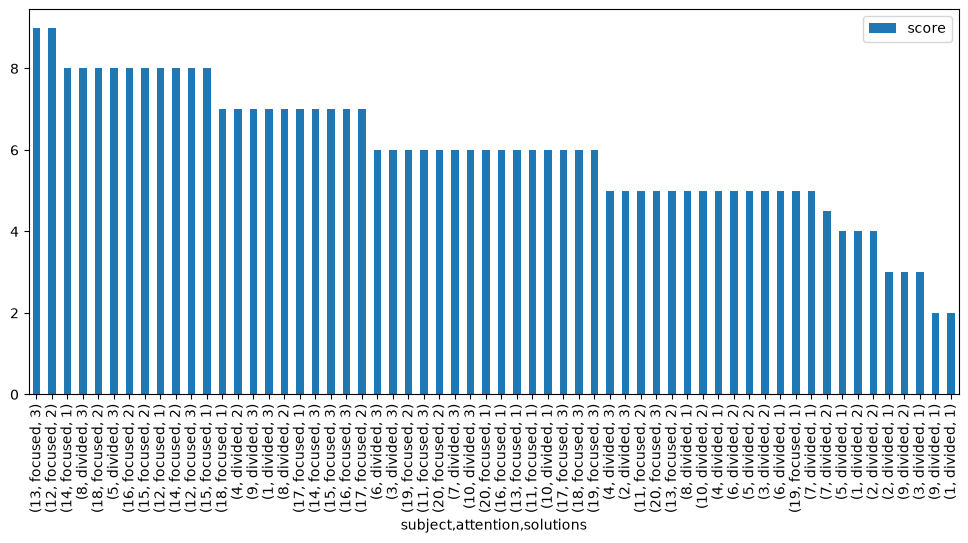

In [117]:
attention1.sort_values('score', ascending=False).plot.bar(figsize=(12,5))
plt.show()

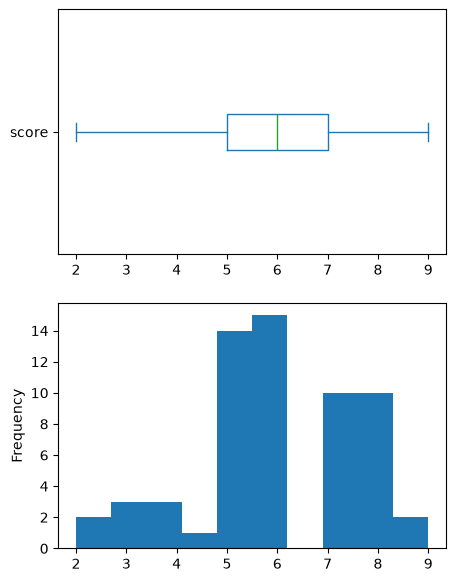

In [84]:
fig, ax = plt.subplots(2,1, figsize=(5,7))
attention1.score.plot.box(vert=False, ax=ax[0])
attention1.score.plot.hist(ax=ax[1])
plt.show()

### Wide form 

In [89]:
# attention.pivot(index=['subject','attention'], columns=['solutions'], values='score')

In [68]:
attention2a = attention1.score.unstack()
attention2a

,solutions,1,2,3
subject,attention,,,
1,divided,2.0,4.0,7.0
2,divided,3.0,4.0,5.0
3,divided,3.0,5.0,6.0
4,divided,5.0,7.0,5.0
5,divided,4.0,5.0,8.0
6,divided,5.0,5.0,6.0
7,divided,5.0,4.5,6.0
8,divided,5.0,7.0,8.0
9,divided,2.0,3.0,7.0


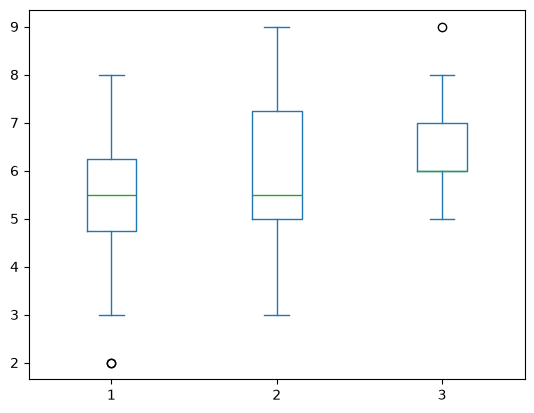

In [69]:
attention2a.plot.box()
plt.show()

In [87]:
# attention.pivot(index=['subject','solutions'], columns=['attention'], values='score')

In [126]:
attention2b = attention1.swaplevel(i=1, j=2, axis=0).score.unstack()
attention2b

attention          divided  focused
subject solutions                  
1       1              2.0      NaN
        2              4.0      NaN
        3              7.0      NaN
2       1              3.0      NaN
        2              4.0      NaN
        3              5.0      NaN
3       1              3.0      NaN
        2              5.0      NaN
        3              6.0      NaN
4       1              5.0      NaN
        2              7.0      NaN
        3              5.0      NaN
5       1              4.0      NaN
        2              5.0      NaN
        3              8.0      NaN
6       1              5.0      NaN
        2              5.0      NaN
        3              6.0      NaN
7       1              5.0      NaN
        2              4.5      NaN
        3              6.0      NaN
8       1              5.0      NaN
        2              7.0      NaN
        3              8.0      NaN
9       1              2.0      NaN
        2              3.0      NaN
        3              7.0      NaN
10      1              6.0      NaN
        2              5.0      NaN
        3              6.0      NaN
11      1              NaN      6.0
        2              NaN      5.0
        3              NaN      6.0
12      1              NaN      8.0
        2              NaN      9.0
        3              NaN      8.0
13      1              NaN      6.0
        2              NaN      5.0
        3              NaN      9.0
14      1              NaN      8.0
        2              NaN      8.0
        3              NaN      7.0
15      1              NaN      8.0
        2              NaN      8.0
        3              NaN      7.0
16      1              NaN      6.0
        2              NaN      8.0
        3              NaN      7.0
17      1              NaN      7.0
        2              NaN      7.0
        3              NaN      6.0
18      1              NaN      7.0
        2              NaN      8.0
        3              NaN      6.0
19      1              NaN      5.0
        2              NaN      6.0
        3              NaN      6.0
20      1              NaN      6.0
        2              NaN      6.0
        3              NaN      5.0

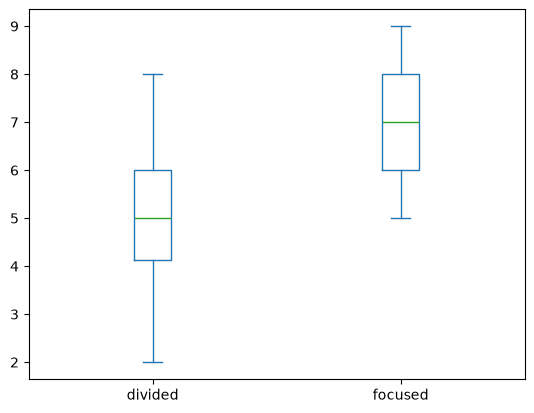

In [123]:
attention2b.plot.box()
plt.show()



:::{note}
By unstacking in this form, we can learn something about the experimental design.

Note that the test population is divided into two groups by `attention`.
:::

In [133]:
# attention2c = attention.pivot(index=['subject'], columns=['attention','solutions'], values='score').sort_index(axis=1)
attention2c = attention2b.unstack().sort_index(axis=1)
attention2c

attention divided           focused          
solutions       1    2    3       1    2    3
subject                                      
1             2.0  4.0  7.0     NaN  NaN  NaN
2             3.0  4.0  5.0     NaN  NaN  NaN
3             3.0  5.0  6.0     NaN  NaN  NaN
4             5.0  7.0  5.0     NaN  NaN  NaN
5             4.0  5.0  8.0     NaN  NaN  NaN
6             5.0  5.0  6.0     NaN  NaN  NaN
7             5.0  4.5  6.0     NaN  NaN  NaN
8             5.0  7.0  8.0     NaN  NaN  NaN
9             2.0  3.0  7.0     NaN  NaN  NaN
10            6.0  5.0  6.0     NaN  NaN  NaN
11            NaN  NaN  NaN     6.0  5.0  6.0
12            NaN  NaN  NaN     8.0  9.0  8.0
13            NaN  NaN  NaN     6.0  5.0  9.0
14            NaN  NaN  NaN     8.0  8.0  7.0
15            NaN  NaN  NaN     8.0  8.0  7.0
16            NaN  NaN  NaN     6.0  8.0  7.0
17            NaN  NaN  NaN     7.0  7.0  6.0
18            NaN  NaN  NaN     7.0  8.0  6.0
19            NaN  NaN  NaN     5.0  6.0  6.0
20            NaN  NaN  NaN     6.0  6.0  5.0

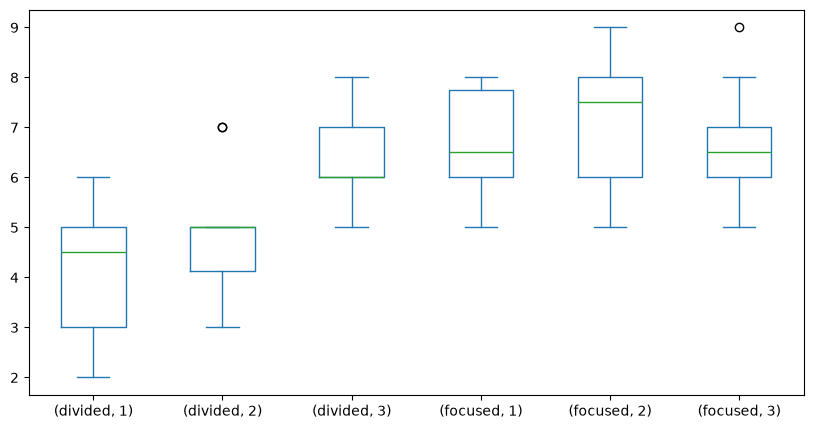

In [134]:
attention2c.plot.box(figsize=(10,5))
plt.show()

### Wide form aggregated

To learn something from the data, we want to aggregate over the population.

We want to know if it matters in general to have you attention focused or divided when performing a task.

We can use either `.pivot_table()` or `.groupby()` and `.unstack()` to do this.

In [75]:
attention3 = attention.pivot_table(index="attention", columns="solutions", values="score", aggfunc="median")
attention3

solutions,1,2,3
attention,,,
divided,4.5,5.0,6.0
focused,6.5,7.5,6.5


In [85]:
attention.groupby(['attention','solutions']).score.median().unstack()

solutions,1,2,3
attention,,,
divided,4.5,5.0,6.0
focused,6.5,7.5,6.5


The simplest way to view the results of the experiment is with a grouped bar chart.

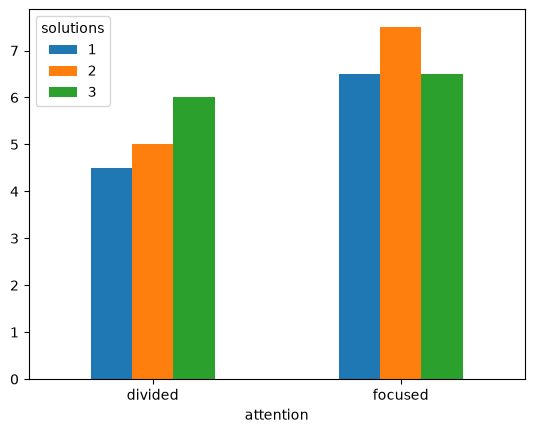

In [77]:
attention3.plot.bar(rot=0)
plt.show()

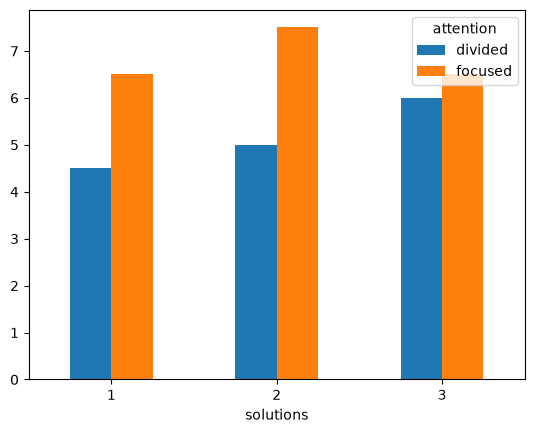

In [81]:
attention3.T.plot.bar(rot=0)
plt.show()